# Pipeline Evaluation

Reads articles from `benchmark.csv`, runs them through the pipeline in-memory
(no DB writes), and compares decisions against ground-truth `should_keep` labels.

Run after any change to thresholds, BM25 terms, weights, or the LLM prompt.

In [1]:
import sys
import uuid
from datetime import datetime
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
from dotenv import load_dotenv

load_dotenv()

sys.path.insert(0, '..')

from services.ingest_service import IngestService
from models import NewsEntry

BENCHMARK_PATH = '../data/benchmark.csv'
EVAL_DIR       = Path('eval_runs')
EVAL_DIR.mkdir(exist_ok=True)

# Label this run — change to describe what you changed
RUN_LABEL = 'optimize1'  # e.g. 'add_bm25_terms', 'lower_discard_threshold'

In [2]:
# Load benchmark ground truth
benchmark = pd.read_csv(BENCHMARK_PATH)
benchmark['should_keep'] = benchmark['should_keep'].astype(bool)
print(f'Benchmark articles: {len(benchmark)}')
print(benchmark.groupby('source')['should_keep'].agg(['sum', 'count', 'mean']).round(2))

Benchmark articles: 113
              sum  count  mean
source                        
ars-technica   28     45  0.62
reddit          4     68  0.06


In [3]:
# Build NewsEntry objects from benchmark
articles = [
    NewsEntry(
        id=row['article_id'],
        source=row['source'],
        title=row['title'],
        body=row['body'] if pd.notna(row['body']) else '',
        published_at=row['published_at'],
    )
    for _, row in benchmark.iterrows()
]
print(f'Articles ready: {len(articles)}')

Articles ready: 113


In [4]:
# Run pipeline in-memory — no DB writes
service = IngestService()
run_id  = str(uuid.uuid4())

print('Running pipeline (LLM calls will take a few minutes)...')
results = service.process_articles(articles, run_id=run_id, persist=False)
print(f'Done. Kept: {len(results)}/{len(articles)}')

Running pipeline (LLM calls will take a few minutes)...
Done. Kept: 31/113


In [5]:
# Build results dataframe and join with ground truth
df_results = pd.DataFrame([
    {
        'article_id':        r.id,
        'pipeline_keep':     r.keep,
        'decision_source':   r.decision_source,
        'fused_score':       r.fused_score,
        'lexical_score':     r.lexical_score,
        'semantic_score':    r.semantic_score,
        'freshness_score':   r.freshness_score,
        'llm_relevance_score': r.llm_relevance_score,
        'llm_reason':        r.llm_reason,
    }
    for r in service._last_all_results  # see note below
])

df = benchmark[['article_id', 'source', 'title', 'should_keep', 'confidence']].merge(
    df_results, on='article_id', how='inner'
)
print(f'Matched: {len(df)}')
print(df['decision_source'].value_counts())

Matched: 113
decision_source
auto_discard    58
llm_judge       54
auto_keep        1
Name: count, dtype: int64


In [7]:
# Overall metrics
y_true = df['should_keep'].astype(int)
y_pred = df['pipeline_keep'].astype(int)

precision = precision_score(y_true, y_pred, zero_division=0)
recall    = recall_score(y_true, y_pred, zero_division=0)
f1        = f1_score(y_true, y_pred, zero_division=0)
cm        = confusion_matrix(y_true, y_pred)

print('=== Pipeline Evaluation ===')
print(f'Precision : {precision:.3f}  (of articles kept, how many should be kept)')
print(f'Recall    : {recall:.3f}  (of articles that should be kept, how many were kept)')
print(f'F1        : {f1:.3f}')
print()
print(pd.DataFrame(cm,
    index  =['GT: discard', 'GT: keep'],
    columns=['Pred: discard', 'Pred: keep']))

=== Pipeline Evaluation ===
Precision : 0.806  (of articles kept, how many should be kept)
Recall    : 0.781  (of articles that should be kept, how many were kept)
F1        : 0.794

             Pred: discard  Pred: keep
GT: discard             75           6
GT: keep                 7          25


In [8]:
# False negatives — should keep, pipeline discarded
fn = df[(df['should_keep']) & (~df['pipeline_keep'])].sort_values('fused_score', ascending=False)
print(f'False negatives: {len(fn)}')
pd.set_option('display.max_colwidth', 80)
fn[['source', 'decision_source', 'fused_score', 'lexical_score',
    'semantic_score', 'freshness_score', 'confidence', 'title']].round(2)

False negatives: 7


,source,decision_source,fused_score,lexical_score,semantic_score,freshness_score,confidence,title
15,ars-technica,auto_discard,0.42,0.25,0.69,0.00,88,Mandiant releases rainbow table that cracks weak admin password in 12 hours
87,reddit,auto_discard,0.36,0.00,0.72,0.71,78,Stay Vigilant
33,ars-technica,auto_discard,0.32,0.00,0.65,0.13,88,"After hackers hit an Iowa company, cars around the country failed to start"
30,ars-technica,auto_discard,0.32,0.00,0.65,0.00,88,Password managers’ promise that they can’t see your vaults isn’t always true
7,ars-technica,auto_discard,0.31,0.00,0.62,0.00,92,Browser extensions with 8 million users collect extended AI conversations
0,ars-technica,auto_discard,0.31,0.00,0.61,0.00,92,5 plead guilty to laptop farm and ID theft scheme to land North Koreans US I...
23,ars-technica,auto_discard,0.29,0.00,0.58,0.00,88,Web portal leaves kids’ chats with AI toy open to anyone with Gmail account


In [9]:
# False positives — should discard, pipeline kept
fp = df[(~df['should_keep']) & (df['pipeline_keep'])].sort_values('fused_score', ascending=False)
print(f'False positives: {len(fp)}')
fp[['source', 'decision_source', 'fused_score', 'lexical_score',
    'semantic_score', 'freshness_score', 'confidence', 'title']].round(2)

False positives: 6


,source,decision_source,fused_score,lexical_score,semantic_score,freshness_score,confidence,title
25,ars-technica,llm_judge,0.62,1.00,0.64,0.00,78,Google quantum-proofs HTTPS by squeezing 15kB of data into 700-byte space
38,ars-technica,llm_judge,0.57,0.78,0.68,0.56,84,Internet Yiff Machine: We hacked 93GB of “anonymous” crime tips
26,ars-technica,llm_judge,0.54,0.66,0.68,0.00,92,Malicious packages for dYdX cryptocurrency exchange empties user wallets
64,reddit,llm_judge,0.51,0.64,0.64,0.66,95,OneDrive (iOS) v16.35.2 causes app to crash and close when trying to access ...
1,ars-technica,llm_judge,0.48,0.52,0.65,0.00,78,Critics scoff after Microsoft warns AI feature can infect machines and pilfe...
12,ars-technica,llm_judge,0.46,0.46,0.64,0.00,88,ChatGPT falls to new data-pilfering attack as a vicious cycle in AI continues


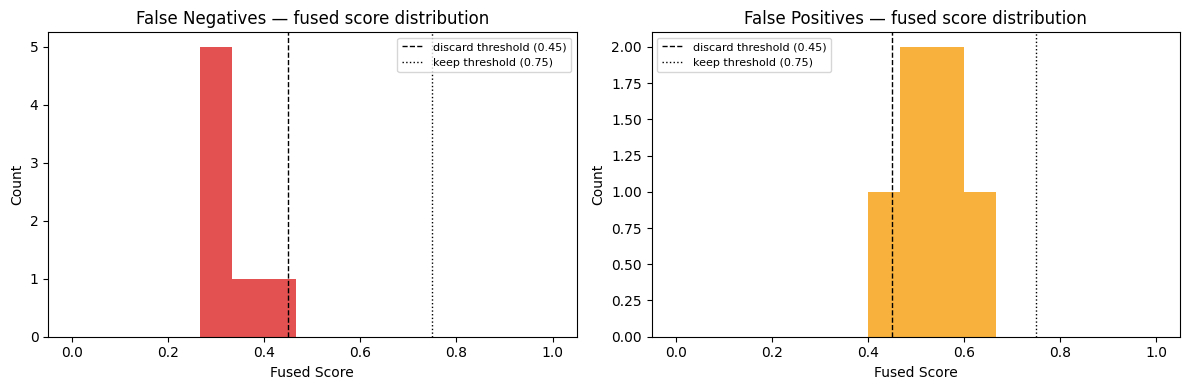

Saved: eval_runs/20260330_004810_optimize1.csv

All runs so far:
run_label          run_ts  precision  recall    f1  false_negatives  false_positives  total  auto_keep  auto_discard  llm_kept  llm_discarded  ars-technica_precision  ars-technica_recall  ars-technica_f1  reddit_precision  reddit_recall  reddit_f1
 baseline 20260329_230459      0.679   0.594 0.633               13                9    113          6            29        22             56                   0.842                0.571            0.681             0.333           0.75      0.462
optimize1 20260330_004810      0.806   0.781 0.794                7                6    113          1            58        30             24                   0.815                0.786            0.800             0.750           0.75      0.750


In [10]:
# Score distributions for errors
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, data, label, color in [
    (axes[0], fn, 'False Negatives', '#dc2626'),
    (axes[1], fp, 'False Positives', '#f59e0b'),
]:
    ax.hist(data['fused_score'], bins=15, color=color, alpha=0.8, range=(0, 1))
    ax.axvline(0.45, color='black', linestyle='--', linewidth=1, label='discard threshold (0.45)')
    ax.axvline(0.75, color='black', linestyle=':',  linewidth=1, label='keep threshold (0.75)')
    ax.set_title(f'{label} — fused score distribution')
    ax.set_xlabel('Fused Score')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# Save this run to eval_runs/
ts       = datetime.now().strftime('%Y%m%d_%H%M%S')
out_path = EVAL_DIR / f'{ts}_{RUN_LABEL}.csv'
df['run_label'] = RUN_LABEL
df['run_ts']    = ts
df.to_csv(out_path, index=False)
print(f'Saved: {out_path}')

# Per-source metrics
source_metrics = {}
for src, grp in df.groupby('source'):
    yt = grp['should_keep'].astype(int)
    yp = grp['pipeline_keep'].astype(int)
    source_metrics[f'{src}_precision'] = round(precision_score(yt, yp, zero_division=0), 3)
    source_metrics[f'{src}_recall']    = round(recall_score(yt, yp, zero_division=0), 3)
    source_metrics[f'{src}_f1']        = round(f1_score(yt, yp, zero_division=0), 3)

# Summary row for easy comparison across runs
summary = {
    'run_label':       RUN_LABEL,
    'run_ts':          ts,
    'precision':       round(precision, 3),
    'recall':          round(recall, 3),
    'f1':              round(f1, 3),
    'false_negatives': len(fn),
    'false_positives': len(fp),
    'auto_keep':       int((df['decision_source'] == 'auto_keep').sum()),
    'auto_discard':    int((df['decision_source'] == 'auto_discard').sum()),
    'llm_kept':        int(((df['decision_source'] == 'llm_judge') & df['pipeline_keep']).sum()),
    'llm_discarded':   int(((df['decision_source'] == 'llm_judge') & ~df['pipeline_keep']).sum()),
    'total':           len(df),
    **source_metrics,
}
summary_path = EVAL_DIR / 'summary.csv'
summary_df   = pd.DataFrame([summary])
if summary_path.exists():
    summary_df = pd.concat([pd.read_csv(summary_path), summary_df], ignore_index=True)
summary_df.to_csv(summary_path, index=False)
print()
print('All runs so far:')
print(summary_df.to_string(index=False))

In [11]:
# Compare two runs side by side
# Set these to the run_label values you want to compare
RUN_A = 'baseline'
RUN_B = RUN_LABEL

summary_df = pd.read_csv(EVAL_DIR / 'summary.csv')
runs = summary_df[summary_df['run_label'].isin([RUN_A, RUN_B])].drop_duplicates('run_label', keep='last')

metrics = [
    'precision', 'recall', 'f1',
    'false_negatives', 'false_positives',
    'auto_keep', 'auto_discard', 'llm_kept', 'llm_discarded',
    'ars-technica_precision', 'ars-technica_recall', 'ars-technica_f1',
    'reddit_precision', 'reddit_recall', 'reddit_f1',
]
metrics = [m for m in metrics if m in runs.columns]

compare = runs.set_index('run_label')[metrics].T
compare['delta'] = compare[RUN_B] - compare[RUN_A]
print(compare.to_string())

run_label               baseline  optimize1   delta
precision                  0.679      0.806   0.127
recall                     0.594      0.781   0.187
f1                         0.633      0.794   0.161
false_negatives           13.000      7.000  -6.000
false_positives            9.000      6.000  -3.000
auto_keep                  6.000      1.000  -5.000
auto_discard              29.000     58.000  29.000
llm_kept                  22.000     30.000   8.000
llm_discarded             56.000     24.000 -32.000
ars-technica_precision     0.842      0.815  -0.027
ars-technica_recall        0.571      0.786   0.215
ars-technica_f1            0.681      0.800   0.119
reddit_precision           0.333      0.750   0.417
reddit_recall              0.750      0.750   0.000
reddit_f1                  0.462      0.750   0.288
